In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0,os.path.join("..","..","dependencies"))
import flopy
import pyemu

In [2]:
m_d = "master_flow_08_highdim_restrict_bcs_flood_full_final_rch_respmatsweep_fullalloc"

In [3]:
pst = pyemu.Pst(os.path.join(m_d,"pest.pst"))

In [4]:
sweep_out_bin_file = os.path.join(m_d,"sweep_out.bin")
if not os.path.exists(sweep_out_bin_file):
    
    import elk03_setup_pst
    elk03_setup_pst.process_respmat(m_d)

In [5]:
df = pyemu.Matrix.from_binary(sweep_out_bin_file).to_dataframe()

In [6]:
df

,k_k:001,ss_k:001,sy_k:000,sy_k:001,oname:bud_otype:lst_usecol:drn_in,oname:bud_otype:lst_usecol:drn_out,oname:bud_otype:lst_usecol:percent_difference,oname:bud_otype:lst_usecol:rcha_in,oname:bud_otype:lst_usecol:rcha_out,oname:bud_otype:lst_usecol:riv_goose_in,...,oname:mfin_otype:lst_usecol:qnt75_input:k_k00,oname:mfin_otype:lst_usecol:qnt75_input:k_k01,oname:mfin_otype:lst_usecol:qnt75_input:ss_k01,oname:mfin_otype:lst_usecol:qnt75_input:sy_k00,oname:mfin_otype:lst_usecol:qnt75_input:sy_k01,oname:mfin_otype:lst_usecol:upper_bound_input:k_k00,oname:mfin_otype:lst_usecol:upper_bound_input:k_k01,oname:mfin_otype:lst_usecol:upper_bound_input:ss_k01,oname:mfin_otype:lst_usecol:upper_bound_input:sy_k00,oname:mfin_otype:lst_usecol:upper_bound_input:sy_k01
base,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,100.0,100.0,0.0001,0.2,0.2,1.000000e+30,1.000000e+30,0.001,0.35,0.35
pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:9_idx2:36,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,100.0,100.0,0.0001,0.2,0.2,1.000000e+30,1.000000e+30,0.001,0.35,0.35
pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:15_idx2:16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,100.0,100.0,0.0001,0.2,0.2,1.000000e+30,1.000000e+30,0.001,0.35,0.35
pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:15_idx2:18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,100.0,100.0,0.0001,0.2,0.2,1.000000e+30,1.000000e+30,0.001,0.35,0.35
pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:16_idx2:21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,100.0,100.0,0.0001,0.2,0.2,1.000000e+30,1.000000e+30,0.001,0.35,0.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:224_idx2:51,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,100.0,100.0,0.0001,0.2,0.2,1.000000e+30,1.000000e+30,0.001,0.35,0.35
pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:225_idx2:67,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,100.0,100.0,0.0001,0.2,0.2,1.000000e+30,1.000000e+30,0.001,0.35,0.35
pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:226_idx2:58,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,100.0,100.0,0.0001,0.2,0.2,1.000000e+30,1.000000e+30,0.001,0.35,0.35
pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:226_idx2:70,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,100.0,100.0,0.0001,0.2,0.2,1.000000e+30,1.000000e+30,0.001,0.35,0.35


In [7]:
obs = pst.observation_data

In [8]:
aredobs = obs.loc[(obs.obsnme.str.contains("auto")) & (obs.obsnme.str.contains("reduction-sum")),:]
aredobs

,obsnme,obsval,weight,obgnme,datetime,file,grpid,i,id,input,...,k,obsname,oname,otype,usecol,wel-pak,observed,count,standard_deviation,distance
obsnme,,,,,,,,,,,,,,,,,,,,,
oname:autoreduce_otype:lst_usecol:reduction-sum_wel-pak:deferred,oname:autoreduce_otype:lst_usecol:reduction-sum_wel-pak:deferred,0.0,0.0,oname:autoreduce_otype:lst_usecol:reduction-sum,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,autoreduce,lst,reduction-sum,deferred,False,1,0,NaN
oname:autoreduce_otype:lst_usecol:reduction-sum_wel-pak:existing,oname:autoreduce_otype:lst_usecol:reduction-sum_wel-pak:existing,0.0,0.0,oname:autoreduce_otype:lst_usecol:reduction-sum,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,autoreduce,lst,reduction-sum,existing,False,1,0,NaN


In [9]:
red_sum = df.loc[:,aredobs.obsnme].sum(axis=1)
red_sum /= red_sum["base"]
trouble_locs = red_sum.loc[red_sum > 1.01].index
keep_locs = red_sum.loc[red_sum <= 1.01].index
trouble_locs

Index(['pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:9_idx2:36',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:15_idx2:16',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:15_idx2:18',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:16_idx2:21',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:18_idx2:17',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:20_idx2:20',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:20_idx2:21',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:22_idx2:18',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:26_idx2:27',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:35_idx2:15',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:37_idx2:14',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:39_idx2:14',
       'pname:defwel_inst:0_ptype:gr_usec

In [10]:
df = df.loc[keep_locs,:]

In [11]:
#gwobs = obs.loc[(obs.usecol.str.startswith("defwel")) | (obs.usecol.str.startswith("exwel")),:].copy()
oobs = obs.loc[pd.notna(obs.usecol),:]
gwobs = oobs.loc[oobs.usecol.str.startswith("exwel"),:].copy()
gwobs["datetime"] = pd.to_datetime(gwobs.datetime)
gwobs = gwobs.loc[gwobs.datetime.dt.year >=2024,:]

gwobs["k"] = gwobs.usecol.apply(lambda x: int(x.split("-")[1][1:]))
gwobs["i"] = gwobs.usecol.apply(lambda x: int(x.split("-")[2][1:]))
gwobs["j"] = gwobs.usecol.apply(lambda x: int(x.split("-")[3][1:]))

In [12]:
sim = flopy.mf6.MFSimulation.load(sim_ws=m_d,load_only=["dis"])
gwf = sim.get_model()
botm = gwf.dis.botm.array

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    skipping package drn...
    skipping package drn...
    skipping package drn...
    skipping package drn...
    skipping package drn...
    skipping package drn...
    skipping package riv...
    skipping package riv...
    skipping package riv...
    skipping package sto...
    skipping package oc...
    skipping package ic...
    skipping package npf...
    skipping package rch...
    skipping package wel...
    skipping package obs...
    skipping package wel...
    skipping package ims6...


In [13]:
gwobs["botm"] = gwobs.apply(lambda x: botm[x.k,x.i,x.j],axis=1)

In [14]:
leveldf = df.loc[:,gwobs.obsnme].copy()
deltadf = leveldf.loc["base",:] - leveldf  

In [15]:
deltadf.max(axis=0).sort_values()

oname:transhds_otype:lst_usecol:exwel-k1-i10-j29_datetime:2024-01-01      0.000000
oname:transhds_otype:lst_usecol:exwel-k1-i261-j25_datetime:2024-03-01     0.000000
oname:transhds_otype:lst_usecol:exwel-k1-i106-j30_datetime:2024-01-01     0.000000
oname:transhds_otype:lst_usecol:exwel-k1-i106-j30_datetime:2024-02-01     0.000000
oname:transhds_otype:lst_usecol:exwel-k1-i186-j51_datetime:2024-02-01     0.000000
                                                                           ...    
oname:transhds_otype:lst_usecol:exwel-k1-i38-j34_datetime:2041-10-01     19.244791
oname:transhds_otype:lst_usecol:exwel-k1-i38-j34_datetime:2042-09-01     19.401394
oname:transhds_otype:lst_usecol:exwel-k1-i38-j34_datetime:2042-10-01     19.502200
oname:transhds_otype:lst_usecol:exwel-k1-i38-j34_datetime:2043-09-01     19.547653
oname:transhds_otype:lst_usecol:exwel-k1-i38-j34_datetime:2043-10-01     19.716059
Length: 54948, dtype: float64

In [16]:
bvec = gwobs.botm.values.copy()

In [17]:
tol = 1.0
bvec += tol

In [18]:
bvec

array([1089.937, 1089.937, 1089.937, ..., 1099.694, 1099.694, 1099.694])

In [20]:
vals = leveldf.values.copy()
satthickvals = np.zeros_like(vals) - 999
neardry = np.zeros_like(vals) - 999
for i in range(leveldf.shape[0]):
    vvals = vals[i,:]
    svals = vvals - bvec
    mmvals = np.zeros_like(vvals)
    mmvals[np.where(vvals<bvec)] = 1.0
    neardry[i,:] = mmvals  
    satthickvals[i,:] = svals


In [21]:
stdf = pd.DataFrame(satthickvals,index=leveldf.index,columns=leveldf.columns)

In [22]:
stdeltadf = stdf.loc["base",:] - stdf

In [23]:
neardry = pd.DataFrame(neardry,index=leveldf.index,columns=leveldf.columns)

<Axes: ylabel='Frequency'>

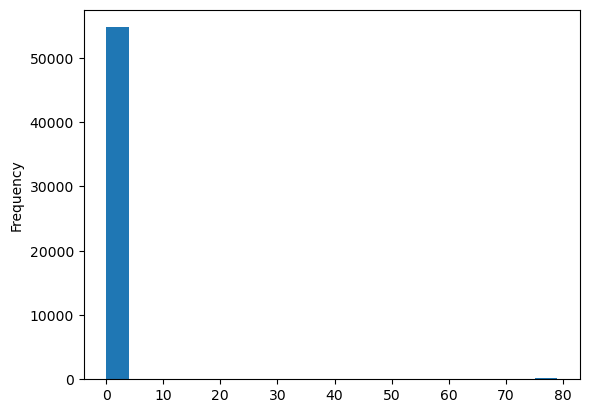

In [24]:
neardry.sum().sort_values().plot(kind="hist",bins=20)

In [25]:
base = neardry.loc["base"]

not_already_dry = base.loc[base==0].index


In [26]:
gwobs = gwobs.loc[not_already_dry,:]
leveldf = leveldf.loc[:,gwobs.obsnme]
bvec = gwobs.botm.values.copy()

In [28]:
vals = leveldf.values.copy()
satthickvals = np.zeros_like(vals) - 999
neardry = np.zeros_like(vals) - 999
for i in range(leveldf.shape[0]):
    vvals = vals[i,:]
    svals = vvals - bvec
    mmvals = np.zeros_like(vvals)
    mmvals[np.where(vvals<bvec)] = 1.0
    neardry[i,:] = mmvals  
    satthickvals[i,:] = svals

In [29]:
neardry = pd.DataFrame(neardry,index=leveldf.index,columns=leveldf.columns)
neardry.sum().sum()

0.0

In [50]:
deltadf = leveldf.loc["base",:] - leveldf  

In [51]:
deltadf.max().sort_values()

oname:transhds_otype:lst_usecol:exwel-k1-i10-j29_datetime:2024-01-01      0.000000
oname:transhds_otype:lst_usecol:exwel-k1-i204-j43_datetime:2024-02-01     0.000000
oname:transhds_otype:lst_usecol:exwel-k1-i204-j43_datetime:2024-01-01     0.000000
oname:transhds_otype:lst_usecol:exwel-k1-i204-j36_datetime:2024-02-01     0.000000
oname:transhds_otype:lst_usecol:exwel-k1-i204-j36_datetime:2024-01-01     0.000000
                                                                           ...    
oname:transhds_otype:lst_usecol:exwel-k1-i38-j34_datetime:2041-10-01     19.244791
oname:transhds_otype:lst_usecol:exwel-k1-i38-j34_datetime:2042-09-01     19.401394
oname:transhds_otype:lst_usecol:exwel-k1-i38-j34_datetime:2042-10-01     19.502200
oname:transhds_otype:lst_usecol:exwel-k1-i38-j34_datetime:2043-09-01     19.547653
oname:transhds_otype:lst_usecol:exwel-k1-i38-j34_datetime:2043-10-01     19.716059
Length: 54768, dtype: float64

In [52]:
print(deltadf.shape)
deltadf = deltadf.loc[deltadf.index.drop("base"),:]
print(deltadf.shape)
pyemu.Matrix.from_dataframe(deltadf).to_dense(os.path.join(m_d,"respmat.bin"))

(79, 54768)
(78, 54768)


In [53]:
gwobs.to_csv(os.path.join(m_d,"respmat_obs_info.csv"))
leveldf.loc["base"].to_csv(os.path.join(m_d,"base_levels.csv"))

In [54]:
with open(os.path.join(m_d,"trouble.txt"),'w') as f:
    for t in trouble_locs:
        f.write(t+"\n")

In [56]:
trouble_locs

Index(['pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:9_idx2:36',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:15_idx2:16',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:15_idx2:18',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:16_idx2:21',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:18_idx2:17',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:20_idx2:20',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:20_idx2:21',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:22_idx2:18',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:26_idx2:27',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:35_idx2:15',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:37_idx2:14',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:39_idx2:14',
       'pname:defwel_inst:0_ptype:gr_usec

In [63]:
pe = pyemu.Matrix.from_binary(filename=os.path.join(m_d,"sweep_in.bin")).to_dataframe()
pe.index

Index(['base',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:9_idx2:36',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:15_idx2:16',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:15_idx2:18',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:16_idx2:21',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:18_idx2:17',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:20_idx2:20',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:20_idx2:21',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:22_idx2:18',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:26_idx2:27',
       ...
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:215_idx2:62',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:216_idx2:66',
       'pname:defwel_inst:0_ptype:gr_usecol:3_pstyle:m_idx0:1_idx1:217_idx2:69',
       'pnam

In [71]:
obs = pst.observation_data
obs["obsval"] = df.loc["base",obs.obsnme]

In [72]:
par = pst.parameter_data
par.loc[pe.columns,"parval1"] = pe.loc["base",:].values
dpar = par.loc[par.pname=="defwel",:].copy()
dpar.shape

(119, 22)

In [73]:
dpar.parval1.sum()

0.0

In [74]:
par.loc[dpar.parnme,"parval1"] = 1.0
par.loc[dpar.parnme,"parval1"].sum()

119.0

In [75]:
par.loc[trouble_locs,"parval1"] = 0.0
par.loc[dpar.parnme,"parval1"].sum()

78.0

In [76]:
pst.control_data.noptmax = 0
pst.write(os.path.join(m_d,"test.pst"),version=2)
pyemu.os_utils.run("pestpp-ies test.pst",cwd=m_d)


noptmax:0, npar_adj:15055, nnz_obs:308733
./pestpp-ies test.pst


             pestpp-ies: a GLM iterative ensemble smoother

                   by the PEST++ development team


version: 5.2.19
binary compiled on May  9 2025 at 08:04:12

started at 01/14/26 08:46:59
...processing command line: ' ./pestpp-ies test.pst'
...using serial run manager

using control file: "test.pst"
in directory: "/Users/jwhite/Dev/NDDWR.C001.ASR-GW/models/elk/master_flow_08_highdim_restrict_bcs_flood_full_final_rch_respmatsweep_fullalloc"
on host: "jwhites-MacBook-Pro.local"

processing control file test.pst

Note: 'NOPTMAX' == 0, switching to forgiveness mode when checking inputs

noptmax = 0, resetting max_run_fail = 1
parameter warning: 41 parameters are at lower bound
parameter warning: 78 parameters are at upper bound
checking model IO files...done
              starting serial run manager ...


  ---  initializing  ---  
...checking phi factors in file phi_facs.csv

  ---  'noptmax'=0, running control

/Users/jwhite/Dev/NDDWR.C001.ASR-GW/models/elk/master_flow_08_highdim_restrict_bcs_flood_full_final_rch_respmatsweep_fullalloc/forward_run.py:523: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
/Users/jwhite/Dev/NDDWR.C001.ASR-GW/models/elk/master_flow_08_highdim_restrict_bcs_flood_full_final_rch_respmatsweep_fullalloc/forward_run.py:523: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
/Users/jwhite/Dev/NDDWR.C001.ASR-GW/models/elk/master_flow_08_highdim_restrict_bcs_flood_full_final_rch_respmatsweep_fullalloc/forward_run.py:523: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
/Users/jwhite/Dev/NDDWR.C001.ASR-GW/models/elk/master_flow_08_highdim_restrict_bcs_flood_full_final_rch_respmatsweep_fullalloc/forwar

                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                   VERSION 6.3.0 release candidate 07/30/2021
                               ***DEVELOP MODE***

   MODFLOW 6 compiled Dec 29 2021 09:30:50 with Intel(R) Fortran Intel(R) 64
   Compiler for applications running on Intel(R) 64, Version 19.1.3.301 Build
                                20200925_000000

This software is preliminary or provisional and is subject to 
revision. It is being provided to meet the need for timely best 
science. The software has not received final approval by the U.S. 
Geological Survey (USGS). No warranty, expressed or implied, is made 
by the USGS or the U.S. Government as to the functionality of the 
software and related material nor shall the fact of release 
constitute any such warranty. The software is provided on the 
condition that neither the USGS nor the U.S. Government shall be held 
liable for any damages resulting from the autho

/Users/jwhite/Dev/NDDWR.C001.ASR-GW/models/elk/master_flow_08_highdim_restrict_bcs_flood_full_final_rch_respmatsweep_fullalloc/forward_run.py:71: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
/Users/jwhite/Dev/NDDWR.C001.ASR-GW/models/elk/master_flow_08_highdim_restrict_bcs_flood_full_final_rch_respmatsweep_fullalloc/forward_run.py:71: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
/Users/jwhite/Dev/NDDWR.C001.ASR-GW/models/elk/master_flow_08_highdim_restrict_bcs_flood_full_final_rch_respmatsweep_fullalloc/forward_run.py:71: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
/Users/jwhite/Dev/NDDWR.C001.ASR-GW/models/elk/master_flow_08_highdim_restrict_bcs_flood_full_final_rch_respmatsweep_fullalloc/forward_r

                              ZONEBUDGET Version 6
                             U.S. GEOLOGICAL SURVEY
                            VERSION 6.1.1 06/12/2020
............................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

In [77]:
pst.set_res(os.path.join(m_d,"test.base.rei"))

In [79]:
pst.res.loc[aredobs.obsnme,:]

,name,group,measured,modelled,residual,weight
name,,,,,,
oname:autoreduce_otype:lst_usecol:reduction-sum_wel-pak:deferred,oname:autoreduce_otype:lst_usecol:reduction-sum_wel-pak:deferred,oname:autoreduce_otype:lst_usecol:reduction-sum,0.000000e+00,1.869538e+07,-1.869538e+07,0.0
oname:autoreduce_otype:lst_usecol:reduction-sum_wel-pak:existing,oname:autoreduce_otype:lst_usecol:reduction-sum_wel-pak:existing,oname:autoreduce_otype:lst_usecol:reduction-sum,5.470120e+06,1.227917e+07,-6.809051e+06,0.0
